# InGram
This notebook illustrates the computations used to form the weighted relation adjacency matrix, $\mathbf{A}$, on knowledge graphs (KGs) as presented in section 4 of [InGram by Lee et al.](https://arxiv.org/abs/2305.19987). We present the computations for the example KG shown in Figure 3 of Lee et al:

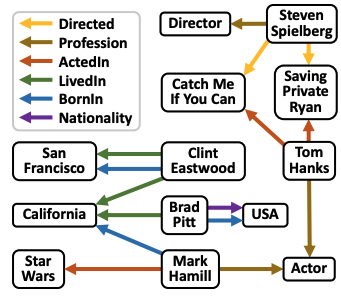

In [48]:
import numpy as np

Initialize the $E_h$ and $E_t$ matrices. Here we set the number of relation (edge) types $m=6$ and the number of entities $n=6$. 

In [59]:
m = 6
n = 13

Eh = np.zeros((n,m))
Et = np.zeros((n,m))

For convenience, we define the following index mappings and functions to ease populating the $E_h$ and $E_t$ matrices.

In [ ]:

jm = {'directed':0, 'profession':1, 'actedin':2, 'livedin':3, 'bornin':4, 'nationality':5}
jm_inv = {v:k for k,v in jm.items()}
im = {'sanfran':0, 'ca':1, 'starwars':2, 'hamill':3, 'pitt':4, 'clint':5, 'catchme':6, 'director':7, 'usa':8, 'spielberg':9, 'spr':10, 'hanks':11, 'actor':12}
im_inv = {v:k for k,v in im.items()}

def ah(head, rel, count):
    Eh[im[head], jm[rel]] = count

def at(tail, rel, count):
    Et[im[tail], jm[rel]] = count

We now populate the non-zero values of $E_h$ and $E_t$. As described in Lee et al., Let $E_h[i, j]$ denote the i-th row and the j-th column element of $E_h$, where $E_h[i, j]$ is the frequency of $v_i$ appearing as a head entity of relation $r_j$ . Similarly, $E_t[i, j]$ is the frequency of $v_i$ appearing as a tail entity of relation $r_j$.

In [51]:
at('sanfran', 'livedin', 1)
at('sanfran', 'bornin', 1)
at('ca', 'livedin', 2)
at('ca', 'bornin', 1)
at('starwars', 'actedin', 1)
at('director', 'profession', 1)
at('catchme', 'directed', 1)
at('catchme', 'actedin', 1)
ah('clint', 'livedin', 2)
ah('clint', 'bornin', 1)
ah('pitt', 'livedin', 1)
ah('pitt', 'nationality', 1)
ah('pitt', 'bornin', 1)
ah('hamill', 'bornin', 1)
ah('hamill', 'actedin', 1)
ah('hamill', 'profession', 1)
at('usa', 'nationality', 1)
at('usa', 'bornin', 1)
ah('spielberg', 'profession', 1)
ah('spielberg', 'directed', 2)
at('spr', 'directed', 1)
at('spr', 'actedin', 1)
ah('hanks', 'actedin', 2)
ah('hanks', 'profession', 1)
at('actor', 'profession', 2)


In [57]:
print(Et)

[[0. 0. 0. 1. 1. 0.]
 [0. 0. 0. 2. 1. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 2. 0. 0. 0. 0.]]


In [53]:
Dh=np.diag(np.sum(Eh, axis=1))
Dt=np.diag(np.sum(Et, axis=1))
Dh.shape, Dt.shape

((13, 13), (13, 13))

In [54]:
Dt

array([[2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 3., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 2., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 2., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 2., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 2.]])

Now let's compute the relation adjacency matrix. We'll use the Moore-Penrose psuedo inverse to invert the diagnoal matrices.

In [58]:
# approximate the square of the inverse with singular value decomposition
Dh_inv = np.linalg.pinv(Dh)
Dh_inv2 = Dh_inv @ Dh_inv
Dt_inv = np.linalg.pinv(Dt)
Dt_inv2 = Dt_inv @ Dt_inv
Ah = Eh.T @ Dh_inv2 @ Eh
At = Et.T @ Dt_inv2 @ Et
A = Ah + At
# print A with 2 decimal places
print(np.round(A, 2))

[[0.94 0.22 0.5  0.   0.   0.  ]
 [0.22 2.33 0.33 0.   0.11 0.  ]
 [0.5  0.33 2.06 0.   0.11 0.  ]
 [0.   0.   0.   1.25 0.81 0.11]
 [0.   0.11 0.11 0.81 0.94 0.36]
 [0.   0.   0.   0.11 0.36 0.36]]


Finally, let's view the relation affinities in readable form:

In [56]:
for i in range(m):
    print(jm_inv[i])
    print("----------")
    for j in range(m):
        a = A[i,j]
        if a > 0 and i != j:
            print(f"  {jm_inv[j]}: {a:.2f}")
    print('\n')

directed
----------
  profession: 0.22
  actedin: 0.50


profession
----------
  directed: 0.22
  actedin: 0.33
  bornin: 0.11


actedin
----------
  directed: 0.50
  profession: 0.33
  bornin: 0.11


livedin
----------
  bornin: 0.81
  nationality: 0.11


bornin
----------
  profession: 0.11
  actedin: 0.11
  livedin: 0.81
  nationality: 0.36


nationality
----------
  livedin: 0.11
  bornin: 0.36


